In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# 1. Membaca Citra Asli
image_path = 'deteksi_daun_jambu.jpeg'
img = cv2.imread(image_path)

# Konversi warna dari BGR ke RGB (untuk ditampilkan via Matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Konversi citra ke ruang warna HSV untuk proses thresholding/masking
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

In [16]:
# 2. Pembuatan Mask Buah (Jambu Air - Kemerahan)
# Warna merah di HSV berada di dua ujung (0-20 dan 160-180).
# Kita buat dua mask lalu digabung.
lower_red1 = np.array([0, 40, 40])
upper_red1 = np.array([20, 255, 255])
mask_red1 = cv2.inRange(img_hsv, lower_red1, upper_red1)

lower_red2 = np.array([160, 40, 40])
upper_red2 = np.array([180, 255, 255])
mask_red2 = cv2.inRange(img_hsv, lower_red2, upper_red2)

# Menggabungkan kedua mask merah
mask_jambu = cv2.bitwise_or(mask_red1, mask_red2)

In [10]:
# 3. Segmentasi Buah
segmentasi_jambu = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_jambu)

In [17]:
# 4. Pembuatan Mask Daun (Hijau)
# Menyesuaikan threshold hijau agar cocok dengan warna daun jambu
lower_green = np.array([25, 40, 40])
upper_green = np.array([90, 255, 255])
mask_daun = cv2.inRange(img_hsv, lower_green, upper_green)

In [18]:
# 5. Segmentasi Daun
segmentasi_daun = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_daun)

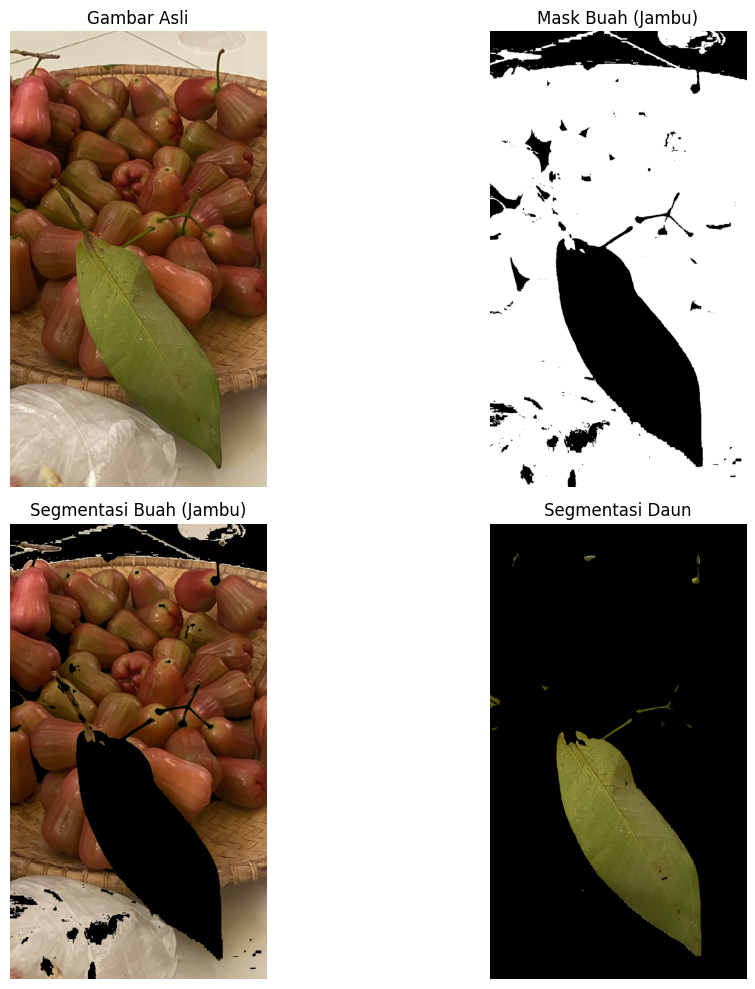

In [19]:
# 6. Menampilkan Hasil
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Output 1: Citra Asli
axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title('Gambar Asli')
axs[0, 0].axis('off')

# Output 2: Mask Buah (Sesuai objek gambar)
axs[0, 1].imshow(mask_jambu, cmap='gray')
axs[0, 1].set_title('Mask Buah (Jambu)')
axs[0, 1].axis('off')

# Output 3: Segmentasi Buah (Sesuai objek gambar)
axs[1, 0].imshow(segmentasi_jambu)
axs[1, 0].set_title('Segmentasi Buah (Jambu)')
axs[1, 0].axis('off')

# Output 4: Segmentasi Daun
axs[1, 1].imshow(segmentasi_daun)
axs[1, 1].set_title('Segmentasi Daun')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()